In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import matplotlib
from matplotlib import rc
from matplotlib import cm


# Load data
df = pd.read_csv('geodesics_table_cv.csv')


# T-test

We want to make two sided t-test to see if geodesic_cv is different from. This is done across all #ensembles. Maybe we want to do within ensemble?


In [5]:
from scipy.stats import ttest_rel

print("MNIST")
print(ttest_rel(df['geolength_cv'], df['euclidean_latent_cv']))
print(ttest_rel(df['geolength_cv'], df['euclidean_latent_cv'], alternative='less'))
print(ttest_rel(df['geolength_cv'], df['euclidean_latent_cv'], alternative='greater'))


MNIST
TtestResult(statistic=-15.938393778516758, pvalue=4.3646523020693937e-29, df=99)
TtestResult(statistic=-15.938393778516758, pvalue=2.1823261510346968e-29, df=99)
TtestResult(statistic=-15.938393778516758, pvalue=1.0, df=99)


# Plots

## Hiostograms of (CV) Coefficient of variation $\frac{\sigma}{\mu}$ of euclidean and geodesic lengths respectively.

/tmp/ipykernel_106314/2854087276.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_for_hists, x='geolength_cv', bins=15, kde=True, stat='density', common_norm=True, palette=geodesic_palette, label='Geodesic', ax=ax)
/tmp/ipykernel_106314/2854087276.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_for_hists, x='euclidean_latent_cv', bins=15, kde=True, stat='density', common_norm=True, palette=euclidean_palette, label='Euclidean', ax=ax)


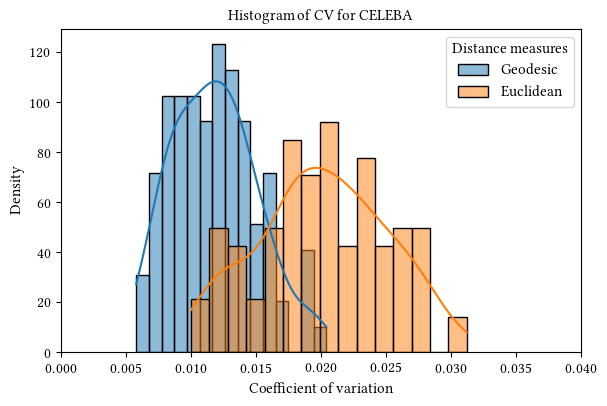

In [9]:
fig, ax = plt.subplots()

# Set a different color palette for each histogram
geodesic_palette = sns.color_palette("Set1")
euclidean_palette = sns.color_palette("Set2")

sns.histplot(df, x='geolength_cv', bins=15, kde=True, stat='density', common_norm=True, palette=geodesic_palette, label='Geodesic', ax=ax)
sns.histplot(df, x='euclidean_latent_cv', bins=15, kde=True, stat='density', common_norm=True, palette=euclidean_palette, label='Euclidean', ax=ax)

# Set x and y labels
ax.set_xlabel(r'Coefficient of variation')
ax.set_ylabel('Density')

# Set the title
ax.set_title('Histogram of CV for CELEBA')

# Add legend
ax.legend(title='Distance measures')
ax.set_xlim(0, 0.04)

# save the plot as pdf
plt.savefig('histogram_mnist.pdf', bbox_inches='tight')